In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
from datasets import load_dataset

dataset = load_dataset("prithivMLmods/Deepfake-vs-Real-60K", split="train")
print(dataset)

In [ ]:
import numpy as np

labels = dataset["label"]

real_idx = np.where(np.array(labels) == 0)[0]
fake_idx = np.where(np.array(labels) == 1)[0]

np.random.shuffle(real_idx)
np.random.shuffle(fake_idx)

real_subset = dataset.select(real_idx[:10000])
fake_subset = dataset.select(fake_idx[:10000])

In [ ]:
from datasets import concatenate_datasets
balanced_dataset = concatenate_datasets([real_subset, fake_subset])

In [ ]:
from torchvision import transforms

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
def batch_transform(examples):
    images = examples["image"]          # list of PIL images
    examples["pixel_values"] = [
        preprocess(img) for img in images
    ]
    return examples

In [ ]:
balanced_dataset= balanced_dataset.map(
    batch_transform,
    batched=True,
    batch_size=32,
    num_proc=os.cpu_count(),   # ← THIS is the key
    remove_columns=["image"]
)

In [ ]:
balanced_dataset.to_parquet("balanced_data.parquet")

In [ ]:
# Save the processed dataset to a folder in /kaggle/working/
balanced_dataset.save_to_disk("my_processed_dataset")

In [ ]:
from IPython.display import FileLink

# This creates a clickable link in your notebook output
FileLink(r'balanced_data.parquet')

# # Split into 80% train, 20% test
# split_dataset = balanced_dataset.train_test_split(test_size=0.2)

# train_ds = split_dataset["train"]
# test_ds = split_dataset["test"]

# print(f"Train size: {len(train_ds)}, Test size: {len(test_ds)}")

In [8]:
from datasets import load_from_disk

# Load the saved dataset
dataset = load_from_disk("my_processed_dataset")

# Check its splits
print(dataset)

Loading dataset from disk:   0%|          | 0/25 [00:00<?, ?it/s]

Dataset({
    features: ['label', 'pixel_values'],
    num_rows: 20000
})


In [9]:
# Ensure your dataset is split correctly
split_dataset = dataset.train_test_split(test_size=0.2)

# Assign the splits to variables
train_ds = split_dataset["train"]
test_ds = split_dataset["test"]

print(f"Train size: {len(train_ds)}, Test size: {len(test_ds)}")

Train size: 16000, Test size: 4000


In [10]:
import numpy as np

In [11]:
# import tensorflow as tf

# def to_tf_dataset(dataset):
#     # Convert lists to numpy arrays
#     images = np.array(dataset['pixel_values'])
#     labels = np.array(dataset['label'])
    
#     # Create the tf.data object
#     return tf.data.Dataset.from_tensor_slices((images, labels))

# # Apply to your splits
# train_tf = to_tf_dataset(train_ds).shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
# test_tf = to_tf_dataset(test_ds).batch(32).prefetch(tf.data.AUTOTUNE)

In [12]:
# Convert the Hugging Face dataset to a tf.data.Dataset
# This does NOT load the images into RAM yet!
def to_tf_dataset(dataset,shuffle_val):
    return dataset.with_format("tf").to_tf_dataset(
        columns=["pixel_values"],
        label_cols=["label"],
        batch_size=32,
        shuffle=shuffle_val
    )

train_tf = to_tf_dataset(split_dataset["train"],True)
test_tf = to_tf_dataset(split_dataset["test"], False)

In [13]:
train_tf.element_spec

(TensorSpec(shape=(None, 3, 224, 224), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int64, name=None))

In [20]:
import tensorflow as tf
def transpose_images(images, labels):
    # Changes (3, 224, 224) -> (224, 224, 3)
    images = tf.transpose(images, perm=[0, 2, 3, 1]) 
    return images, labels

train_tf = train_tf.map(transpose_images, num_parallel_calls=tf.data.AUTOTUNE)
test_tf = test_tf.map(transpose_images, num_parallel_calls=tf.data.AUTOTUNE)

# Verify the new shape
print(train_tf.element_spec)

(TensorSpec(shape=(None, 224, 3, 224), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))


In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Input shape for 224x224 RGB images
input_shape = (224, 224, 3)

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D(2,2),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # Binary classification: real vs fake
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
epochs = 5  # start small, increase later
history = model.fit(
    train_tf,
    validation_data=test_tf,
    epochs=epochs
)

Epoch 1/5


I0000 00:00:1772194751.672164     138 service.cc:152] XLA service 0x7898c0007c20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772194751.672213     138 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772194751.672219     138 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772194753.009541     138 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-27 12:19:15.657585: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-27 12:19:15.806356: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  3/500 ━━━━━━━━━━━━━━━━━━━━ 27s 56ms/step - accuracy: 0.4896 - loss: 1.8895

I0000 00:00:1772194758.548605     138 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


500/500 ━━━━━━━━━━━━━━━━━━━━ 157s 297ms/step - accuracy: 0.9130 - loss: 0.2836 - val_accuracy: 0.9937 - val_loss: 0.0265
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 284ms/step - accuracy: 0.9911 - loss: 0.0298 - val_accuracy: 0.9923 - val_loss: 0.0233
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 137s 274ms/step - accuracy: 0.9935 - loss: 0.0232 - val_accuracy: 0.9910 - val_loss: 0.0236
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 133s 266ms/step - accuracy: 0.9968 - loss: 0.0128 - val_accuracy: 0.9958 - val_loss: 0.0166
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 136s 272ms/step - accuracy: 0.9954 - loss: 0.0142 - val_accuracy: 0.9962 - val_loss: 0.0147


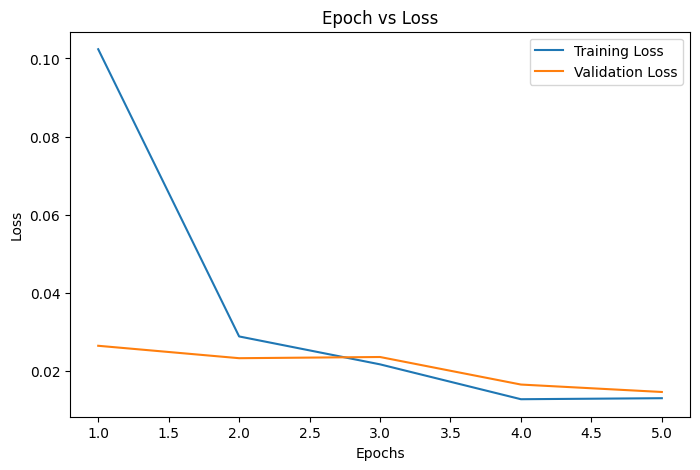

In [19]:
import matplotlib.pyplot as plt

# Extract loss values
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(loss)+1)

plt.figure(figsize=(8,5))
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Epoch vs Loss')
plt.legend()
plt.show()

In [18]:
loss, acc = model.evaluate(test_tf)
print(f"Test Accuracy: {acc*100:.2f}%")

125/125 ━━━━━━━━━━━━━━━━━━━━ 26s 204ms/step - accuracy: 0.9965 - loss: 0.0140
Test Accuracy: 99.62%
